In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

sample_path = "..\\tests\\data\\sample.h5"
sample_dir = Path("..\\tests\\data\\HelenaRunner-0a8221be-38f7-4679-a937-566e6bf83d5a_scan_2")

#### Growth rate comparison

MISHKA growth rates: [0.00579046 0.01296534 0.01915478 0.0240246  0.02637077 0.02518487
 0.01963471 0.00974863]
MISHKA ntor: [3, 5, 7, 10, 15, 20, 30, 50]
CASTOR growth rates: [0.00987508 0.01729812 0.02498402 0.02472613 0.03256174 0.02088353
 0.0325268  0.00970686]
CASTOR ntor: [3, 5, 7, 10, 15, 20, 30, 50]


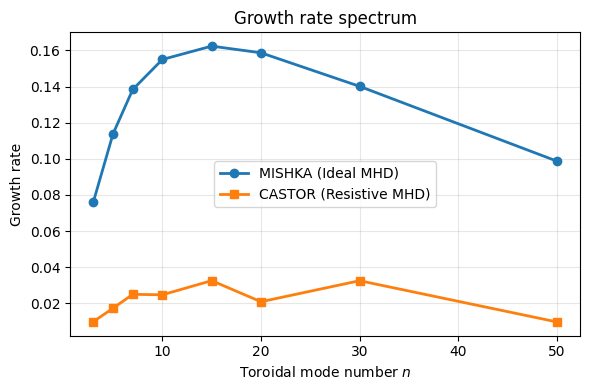

In [2]:

with h5py.File(sample_path, "r") as h5:

    ntor_mishka = sorted(int(key[1:]) for key in h5["mishka"].keys())
    mishka_growth = np.array([
        h5[f"mishka/n{n:03d}/output/ew"][()]
        for n in ntor_mishka
    ])

    ntor_castor = sorted(int(key[1:]) for key in h5["castor"].keys())
    castor_growth = np.array([
        h5[f"castor/n{n:03d}/output/ew"][()]
        for n in ntor_castor
    ])

    print("MISHKA growth rates:", mishka_growth)
    print("MISHKA ntor:", ntor_mishka)
    print("CASTOR growth rates:", castor_growth)
    print("CASTOR ntor:", ntor_castor)


plt.figure(figsize=(6, 4))

plt.plot(ntor_mishka, mishka_growth**(0.5), "o-", lw=2, label="MISHKA (Ideal MHD)")
plt.plot(ntor_castor, castor_growth, "s-", lw=2, label="CASTOR (Resistive MHD)")

plt.xlabel("Toroidal mode number $n$")
plt.ylabel("Growth rate")
plt.title("Growth rate spectrum")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

#### Profiles in "real world" units

Text(0.5, 1.0, '$p$')

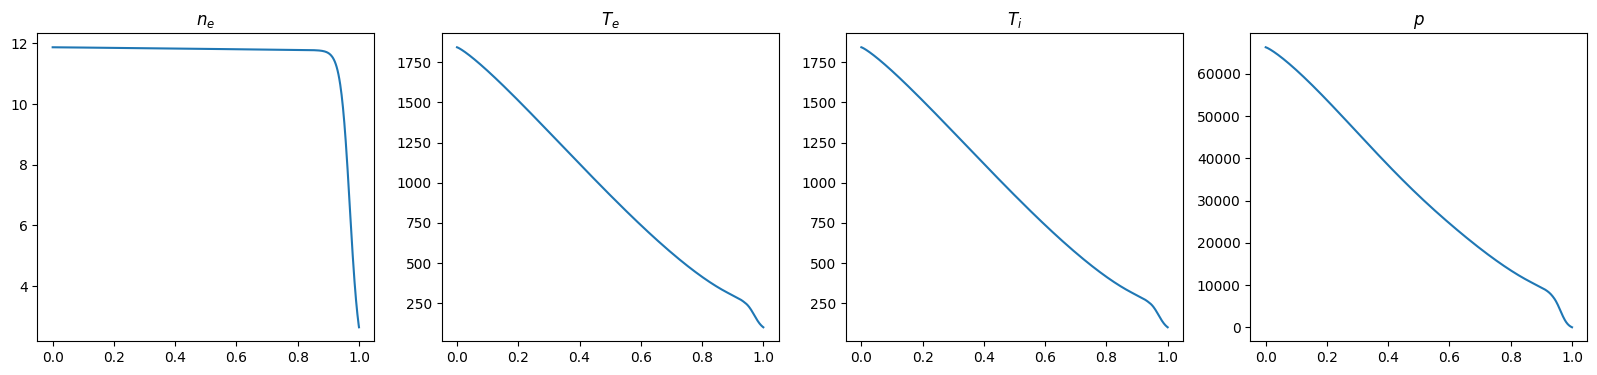

In [3]:
with h5py.File(sample_path, "r") as h5:

    s = h5["equilibrium/realworld/S"][:]
    ne = h5["equilibrium/realworld/ne"][:]
    Te = h5["equilibrium/realworld/Te"][:]
    Ti = h5["equilibrium/realworld/Ti"][:]
    p = h5["equilibrium/realworld/p"][:]

psi = s**2

fig, ax = plt.subplots(1, 4, figsize=(20, 4))

ax[0].plot(psi, ne)
ax[0].set_title(r"$n_e$")

ax[1].plot(psi, Te)
ax[1].set_title(r"$T_e$")

ax[2].plot(psi, Ti)
ax[2].set_title(r"$T_i$")

ax[3].plot(psi, p)
ax[3].set_title(r"$p$")

#### Current

Text(0.5, 1.0, '$J_\\phi$')

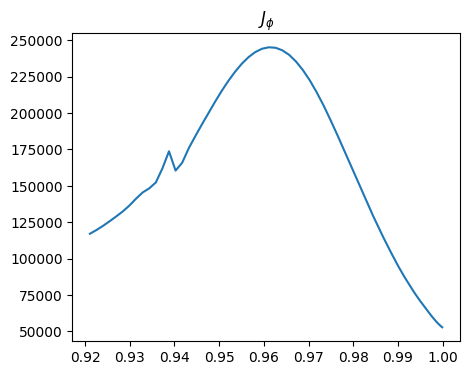

In [4]:
with h5py.File(sample_path, "r") as h5:

    psi = h5["equilibrium/current_density/psi"][:]
    jphi = h5["equilibrium/current_density/jphi"][:]

fig, ax = plt.subplots(1, 1, figsize=(5,4))

ax.plot(psi, jphi)
ax.set_title(r"$J_\phi$")

Text(0.5, 1.0, '$A$')

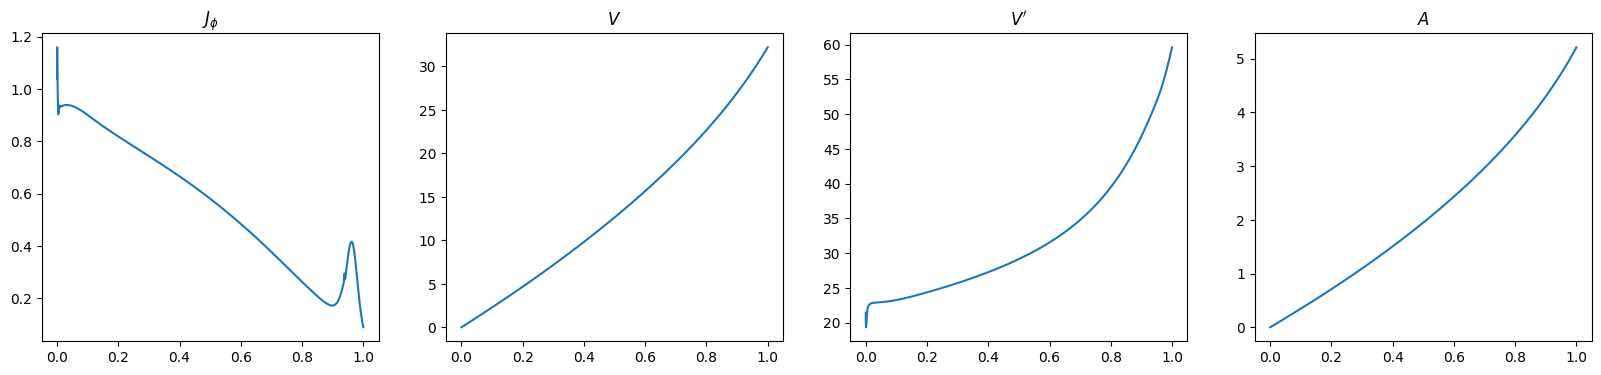

In [5]:
with h5py.File(sample_path, "r") as h5:

    psi = h5["equilibrium/current_volume_area/psi"][:]
    jphi = h5["equilibrium/current_volume_area/jphi"][:]
    vol = h5["equilibrium/current_volume_area/vol"][:]
    volp = h5["equilibrium/current_volume_area/volp"][:]
    area = h5["equilibrium/current_volume_area/area"][:]

fig, ax = plt.subplots(1, 4, figsize=(20, 4))
ax[0].plot(psi, jphi)
ax[0].set_title(r"$J_\phi$")
ax[1].plot(psi, vol)
ax[1].set_title(r"$V$")
ax[2].plot(psi, volp)
ax[2].set_title(r"$V'$")
ax[3].plot(psi, area)
ax[3].set_title(r"$A$")

Text(0.5, 1.0, 'Safety factor')

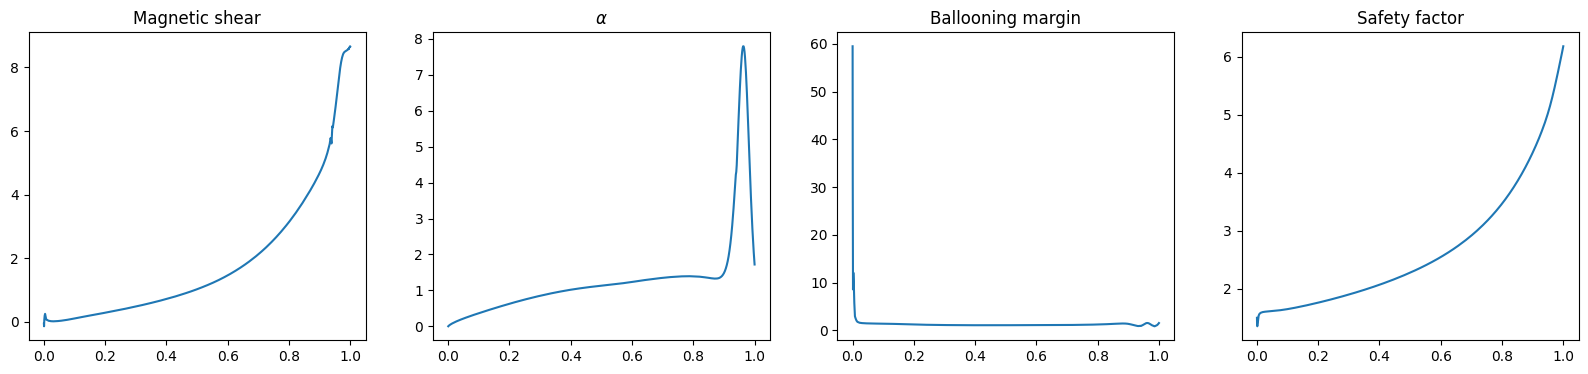

In [6]:
with h5py.File(sample_path, "r") as h5:

    psi = h5["equilibrium/ballooning/psi"][:]
    shear = h5["equilibrium/ballooning/shear"][:]
    alpha = h5["equilibrium/ballooning/alpha"][:]
    fmarg = h5["equilibrium/ballooning/fmarg"][:]
    q = h5["equilibrium/ballooning/q"][:]

fig, ax = plt.subplots(1, 4, figsize=(20,4))

ax[0].plot(psi, shear)
ax[0].set_title("Magnetic shear")

ax[1].plot(psi, alpha)
ax[1].set_title(r"$\alpha$")

ax[2].plot(psi, fmarg)
ax[2].set_title("Ballooning margin")

ax[3].plot(psi, q)
ax[3].set_title("Safety factor")

#### Resistivity

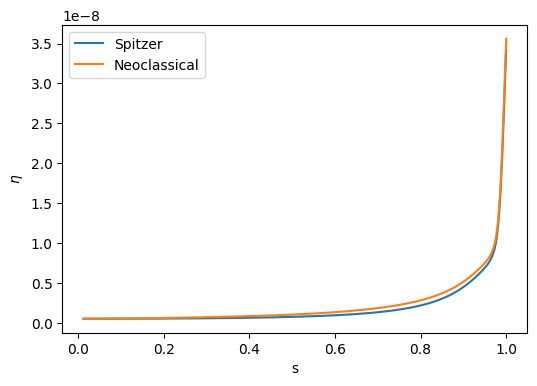

In [7]:
with h5py.File(sample_path, "r") as h5:

    s = h5["equilibrium/resistivity/s"][:]
    eta_spitzer = h5["equilibrium/resistivity/eta_spitzer"][:]
    eta_neo = h5["equilibrium/resistivity/eta_neo"][:]

plt.figure(figsize=(6,4))
plt.plot(s, eta_spitzer, label="Spitzer")
plt.plot(s, eta_neo, label="Neoclassical")
plt.xlabel("s")
plt.ylabel(r"$\eta$")
plt.legend()

#### Stability

In [8]:

stability_code = "mishka"  # or "castor"
ntor = 5  # specify the toroidal mode number

with h5py.File(sample_path, "r") as h5:
    # If IFAST option was used, the mpols used need to be calculated
    ifast = h5[f"{stability_code}/n{ntor:03d}/input/ifast"][()]
    manz = h5[f"{stability_code}/n{ntor:03d}/output/manz"][()]
    
    # Access the stability data for the specified toroidal mode
    growth_rate = h5[f"{stability_code}/n{ntor:03d}/output/ew"][()]
    ev_flat = h5[f"{stability_code}/n{ntor:03d}/output/ev"][()]
    sgrid = h5[f"{stability_code}/n{ntor:03d}/output/sgrid"][()]
    ng = h5[f"{stability_code}/n{ntor:03d}/output/ng"][()]
    ngl = h5[f"{stability_code}/n{ntor:03d}/output/ngl"][()]

    helena_psi = h5["equilibrium/ballooning/psi"][:]
    helena_q = h5["equilibrium/ballooning/q"][:]

helena_s = np.sqrt(helena_psi)


In [9]:

from scipy.interpolate import interp1d

def get_poloidal_modes(ifast, helena_s, helena_q, ntor, manz, ng, cs):
    """From jetlib."""
    if ifast or ifast==1:
        q = interp1d(helena_s, helena_q)(cs)
        mstart = 1 + np.floor(ntor * q-(manz-1)/2)
    else:
        mstart = np.zeros(ng)
    print(min(mstart), max(mstart), manz)
    ms = np.arange(min(mstart), max(mstart) + manz)
    return ms, mstart.astype(int)


def get_eigenfunc(ivar, eigvec, manz, ng, ms, mstart, phase=0, chi=0):
    """From jetlib."""
    vec = np.zeros([len(ms), ng])
    for m in range(manz):
        m_ind = m + mstart - min(mstart)
        r_ind = np.arange(ng)
        vec[m_ind, r_ind] += eigvec[2*ivar-2,0,m,:] * np.cos((mstart+m)*chi + phase) \
                            - eigvec[2*ivar-2,1,m,:] * np.sin((mstart+m)*chi + phase)
    return vec



In [10]:

def read_eigenfunctions_fort22(f22_path):
    with open(f22_path) as f:
        tok = f.read().split()
    data = {}
    p = 0
    data["ew"] = float(tok[p]); p += 1
    data["ewc"] = float(tok[p]); p += 1

    data["ng"] = int(tok[p]); p += 1  # Grid points
    data["manz"] = int(tok[p]); p += 1  # Number of poloidal harmonics
    data["ngl"] = int(tok[p]); p += 1  # Number of variables (always two? 0: V1,V2. 1: dV1/dS, v2 midnode)

    data["rfour"] = np.asarray(tok[p:p+data["manz"]], float)
    p += data["manz"]

    data["sgrid"] = np.asarray(tok[p:p+data["ng"]], float)
    p += data["ng"]
    data["cs"] = data["sgrid"]
    data["psi"] = data["sgrid"]**2

    # Reading eigenvectors
    data["ev"] = np.asarray(tok[p:], float)

    return data

def structure_eigenvectors(ev_flat, ng, manz, ngl):
    """From jetlib.
    Returns the eigenvectors as
    ev[2*ngl, 2, manz, ng]
    """
    nbg = 2 * ngl * manz
    ev = ev_flat.reshape((2, nbg, ng), order='F')
    ev[0,:,0] = 0

    # Reorganizing eigenvectors
    eigvec = np.zeros([2 * ngl, 2, manz, ng])
    
    for i in range(ngl):
        i1 = 2*i*manz
        i2 = 2*i*manz + 1
        m1 = i1 + 2*manz
        # v1, v2
        eigvec[2*i,:,0:manz,:] = ev[:,i1:m1:2,:]
        # dv1/ds, v2 midnode
        eigvec[2*i+1,:,0:manz,:] = ev[:,i2:m1:2,:]

    return eigvec


-1.0 16.0 31


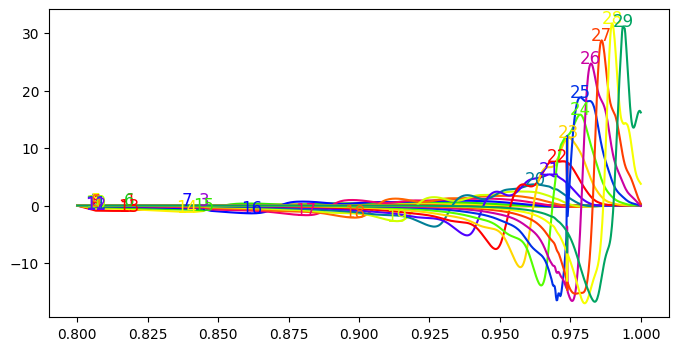

In [11]:
ms, mstart = get_poloidal_modes(ifast, helena_s, helena_q, ntor, manz, ng, sgrid)

ev_h5 = structure_eigenvectors(ev_flat, ng, manz, ngl)
vec_h5 = get_eigenfunc(0, ev_h5, manz, ng, ms, mstart, phase=0, chi=0)


fig, ax = plt.subplots(ncols=1, figsize=(8,4))
cmap = "prism"
colmap = plt.get_cmap(cmap)

for m in range(manz):
    color = colmap(m / len(ms))
    ax.plot(sgrid, vec_h5[m] * 1e4, color=color)

    iym = np.argmax(abs(vec_h5[m]))
    ax.text(sgrid[iym], vec_h5[m, iym]*1e4, str(int(ms[m])),
            size=12, color=color, ha="center")